In [48]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.ensemble import RandomForestClassifier

from sklearn.tree import DecisionTreeClassifier

from sklearn.linear_model import LogisticRegression

In [49]:
import os

os.listdir()

['.config',
 'customer_churn_dataset-training-master.csv',
 'customer_churn_dataset-testing-master.csv',
 'sample_data']

In [50]:
train_df = pd.read_csv("customer_churn_dataset-training-master.csv")
test_df = pd.read_csv("customer_churn_dataset-testing-master.csv")

In [51]:
train_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,Female,39.0,14.0,5.0,18.0,Standard,Annual,932.0,17.0,1.0
1,3.0,65.0,Female,49.0,1.0,10.0,8.0,Basic,Monthly,557.0,6.0,1.0
2,4.0,55.0,Female,14.0,4.0,6.0,18.0,Basic,Quarterly,185.0,3.0,1.0
3,5.0,58.0,Male,38.0,21.0,7.0,7.0,Standard,Monthly,396.0,29.0,1.0
4,6.0,23.0,Male,32.0,20.0,5.0,8.0,Basic,Monthly,617.0,20.0,1.0


In [52]:
train_df.shape

(440833, 12)

In [53]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440833 entries, 0 to 440832
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   CustomerID         440832 non-null  float64
 1   Age                440832 non-null  float64
 2   Gender             440832 non-null  object 
 3   Tenure             440832 non-null  float64
 4   Usage Frequency    440832 non-null  float64
 5   Support Calls      440832 non-null  float64
 6   Payment Delay      440832 non-null  float64
 7   Subscription Type  440832 non-null  object 
 8   Contract Length    440832 non-null  object 
 9   Total Spend        440832 non-null  float64
 10  Last Interaction   440832 non-null  float64
 11  Churn              440832 non-null  float64
dtypes: float64(9), object(3)
memory usage: 40.4+ MB


In [54]:
train_df.isnull().sum()

,0
CustomerID,1
Age,1
Gender,1
Tenure,1
Usage Frequency,1
Support Calls,1
Payment Delay,1
Subscription Type,1
Contract Length,1
Total Spend,1


In [55]:
train_df.duplicated().sum()

np.int64(0)

In [56]:
train_df = train_df.dropna()

In [57]:
train_df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
Usage Frequency,0
Support Calls,0
Payment Delay,0
Subscription Type,0
Contract Length,0
Total Spend,0


In [58]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df["Gender"] = le.fit_transform(train_df["Gender"])
train_df["Subscription Type"] = le.fit_transform(train_df["Subscription Type"])
train_df["Contract Length"] = le.fit_transform(train_df["Contract Length"])

In [59]:
train_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,2.0,30.0,0,39.0,14.0,5.0,18.0,2,0,932.0,17.0,1.0
1,3.0,65.0,0,49.0,1.0,10.0,8.0,0,1,557.0,6.0,1.0
2,4.0,55.0,0,14.0,4.0,6.0,18.0,0,2,185.0,3.0,1.0
3,5.0,58.0,1,38.0,21.0,7.0,7.0,2,1,396.0,29.0,1.0
4,6.0,23.0,1,32.0,20.0,5.0,8.0,0,1,617.0,20.0,1.0


In [61]:
test_df = test_df.dropna()

In [62]:
test_df["Gender"] = le.fit_transform(test_df["Gender"])
test_df["Subscription Type"] = le.fit_transform(test_df["Subscription Type"])
test_df["Contract Length"] = le.fit_transform(test_df["Contract Length"])

In [63]:
test_df.head()

,CustomerID,Age,Gender,Tenure,Usage Frequency,Support Calls,Payment Delay,Subscription Type,Contract Length,Total Spend,Last Interaction,Churn
0,1,22,0,25,14,4,27,0,1,598,9,1
1,2,41,0,28,28,7,13,2,1,584,20,0
2,3,47,1,27,10,2,29,1,0,757,21,0
3,4,35,1,9,12,5,17,1,2,232,18,0
4,5,53,0,58,24,9,2,2,0,533,18,0


In [64]:
X_train = train_df.drop("Churn", axis=1)
y_train = train_df["Churn"]

X_test = test_df.drop("Churn", axis=1)
y_test = test_df["Churn"]

In [65]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(440832, 11)
(440832,)
(64374, 11)
(64374,)


In [66]:
from sklearn.ensemble import RandomForestClassifier

baseline_model = RandomForestClassifier(random_state=42)

baseline_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [ ]:
baseline_pred = baseline_model.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Baseline Model Performance")
print("Accuracy :", accuracy_score(y_test, baseline_pred))
print("Precision:", precision_score(y_test, baseline_pred))
print("Recall   :", recall_score(y_test, baseline_pred))
print("F1 Score :", f1_score(y_test, baseline_pred))

In [26]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [47]:
print(grid_search.best_params_)

{'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}


In [67]:
best_model = grid_search.best_estimator_

optimized_pred = best_model.predict(X_test)

In [68]:
print("Optimized Model Performance")
print("Accuracy :", accuracy_score(y_test, optimized_pred))
print("Precision:", precision_score(y_test, optimized_pred))
print("Recall   :", recall_score(y_test, optimized_pred))
print("F1 Score :", f1_score(y_test, optimized_pred))

Optimized Model Performance
Accuracy : 0.49406592723770465
Precision: 0.4835363532546631
Recall   : 0.9997704391171744
F1 Score : 0.6518211265648218


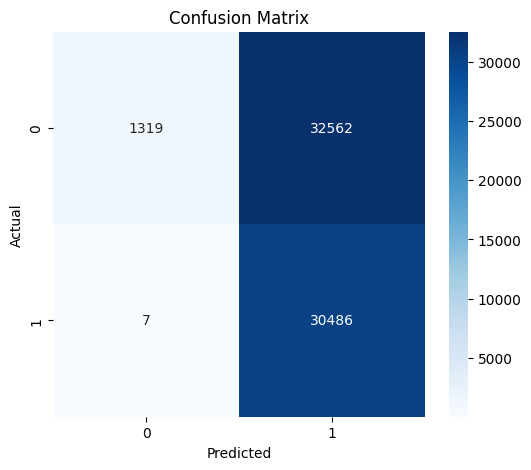

In [69]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, optimized_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [70]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
5,Support Calls,0.169893
1,Age,0.155836
8,Contract Length,0.154603
9,Total Spend,0.133982
6,Payment Delay,0.105747
10,Last Interaction,0.076179
0,CustomerID,0.065652
2,Gender,0.054051
3,Tenure,0.043051
4,Usage Frequency,0.031949


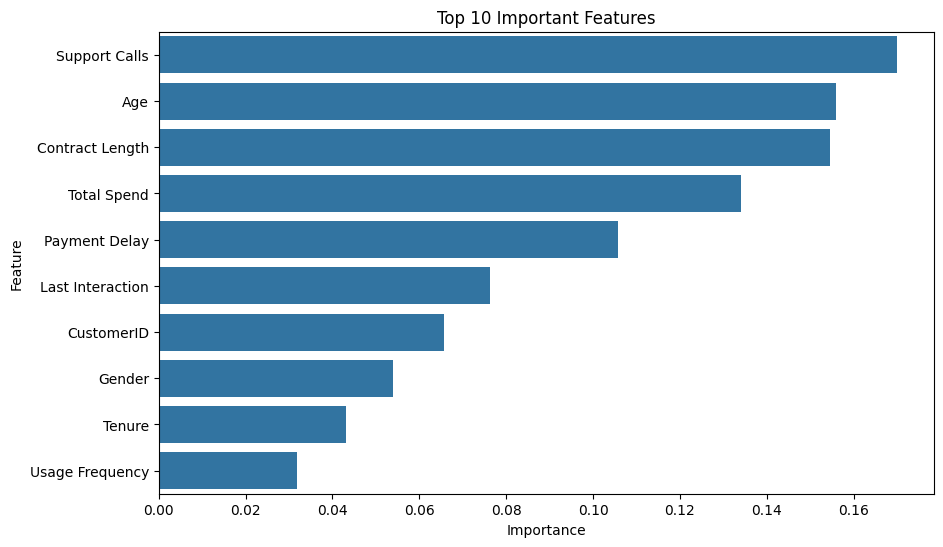

In [71]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")
plt.show()

## Key Factors Influencing Customer Churn

The feature importance analysis shows that **Support Calls** is the most influential feature in predicting customer churn, followed by **Age**, **Contract Length**, **Total Spend**, and **Payment Delay**. These features contribute the most to the model's predictions.

## Recommendations

- Improve customer support to reduce repeated support calls.
- Encourage customers to choose longer contract plans.
- Monitor customers with frequent payment delays.
- Offer retention programs for high-risk customers.
- Increase customer engagement through regular follow-ups.

## Conclusion

A baseline Random Forest model was built and later optimized using GridSearchCV. The optimized model improved Accuracy, Precision, and F1-score compared to the baseline model while maintaining a very high Recall. Feature importance analysis identified Support Calls, Age, Contract Length, Total Spend, and Payment Delay as the most influential factors affecting customer churn.